# Pangeo-Enabled ESM Pattern Scaling (PEEPS)
# libraries and helper functions

For simplicity in this notebook, many of the repeated calculations used for
linear pattern scaling are included as functions in the `helper.py` script,
which is a part of this repository and sourced:

In [1]:
# Load all of the libraries
from matplotlib import pyplot as plt
import pandas as pd
import os
import xarray as xr
import numpy as np
import sklearn as skl
import cftime

import sys
sys.path.append("..")
import fxns


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 12, 6

# easier to read displays in console
pd.set_option('display.max_columns', None)


# Prep where to write the processed data out to
DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(DATA_DIR+"field", exist_ok=True)
os.makedirs(DATA_DIR+"global", exist_ok=True)
os.makedirs(DATA_DIR+"beta", exist_ok=True)
os.makedirs(DATA_DIR+"intercept", exist_ok=True)
os.makedirs(DATA_DIR+"yhat", exist_ok=True)
os.makedirs(DATA_DIR+"error_metrics", exist_ok=True)
os.makedirs(DATA_DIR+"raw_data", exist_ok=True)



In [2]:
# Files that are going to be generated by this script...
tag = 'CanESM5_historical_r10i1p1f1n_npp'

field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    


In [3]:
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

In [4]:
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values

##ACS ?


# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

field

<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [5]:
# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

global_ts

<xarray.Dataset> Size: 2kB
Dimensions:  (time: 165)
Coordinates:
  * time     (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Data variables:
    npp      (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [6]:
# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]


field_with_global


<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [7]:
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

reg

<xarray.Dataset> Size: 133kB
Dimensions:                     (degree: 2, lat: 64, lon: 128)
Coordinates:
  * degree                      (degree) int64 16B 1 0
  * lat                         (lat) float64 512B -87.86 -85.1 ... 85.1 87.86
  * lon                         (lon) float64 1kB 0.0 2.812 ... 354.4 357.2
Data variables:
    field_polyfit_coefficients  (degree, lat, lon) float64 131kB 2.167e-14 .....
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [8]:
beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')


/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


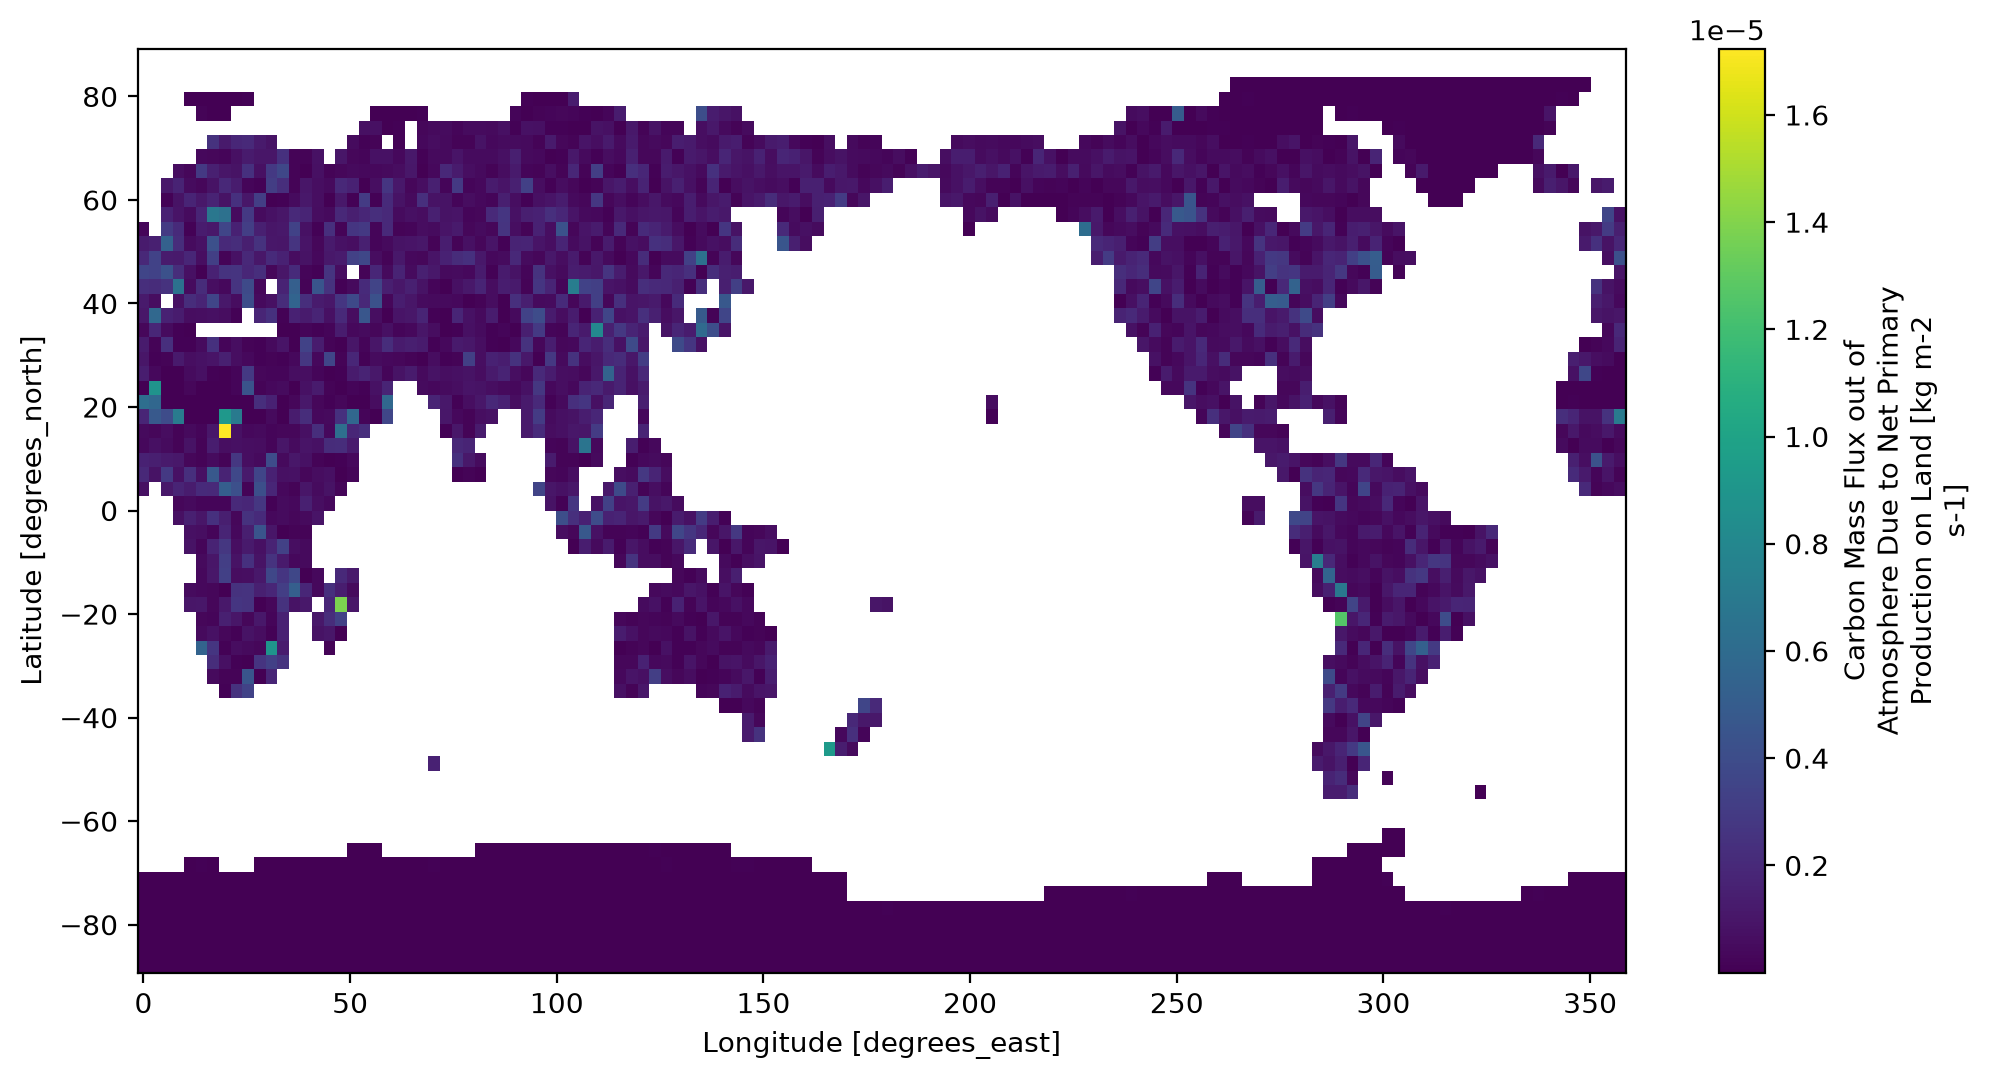

In [9]:
ct_bias.npp.plot()

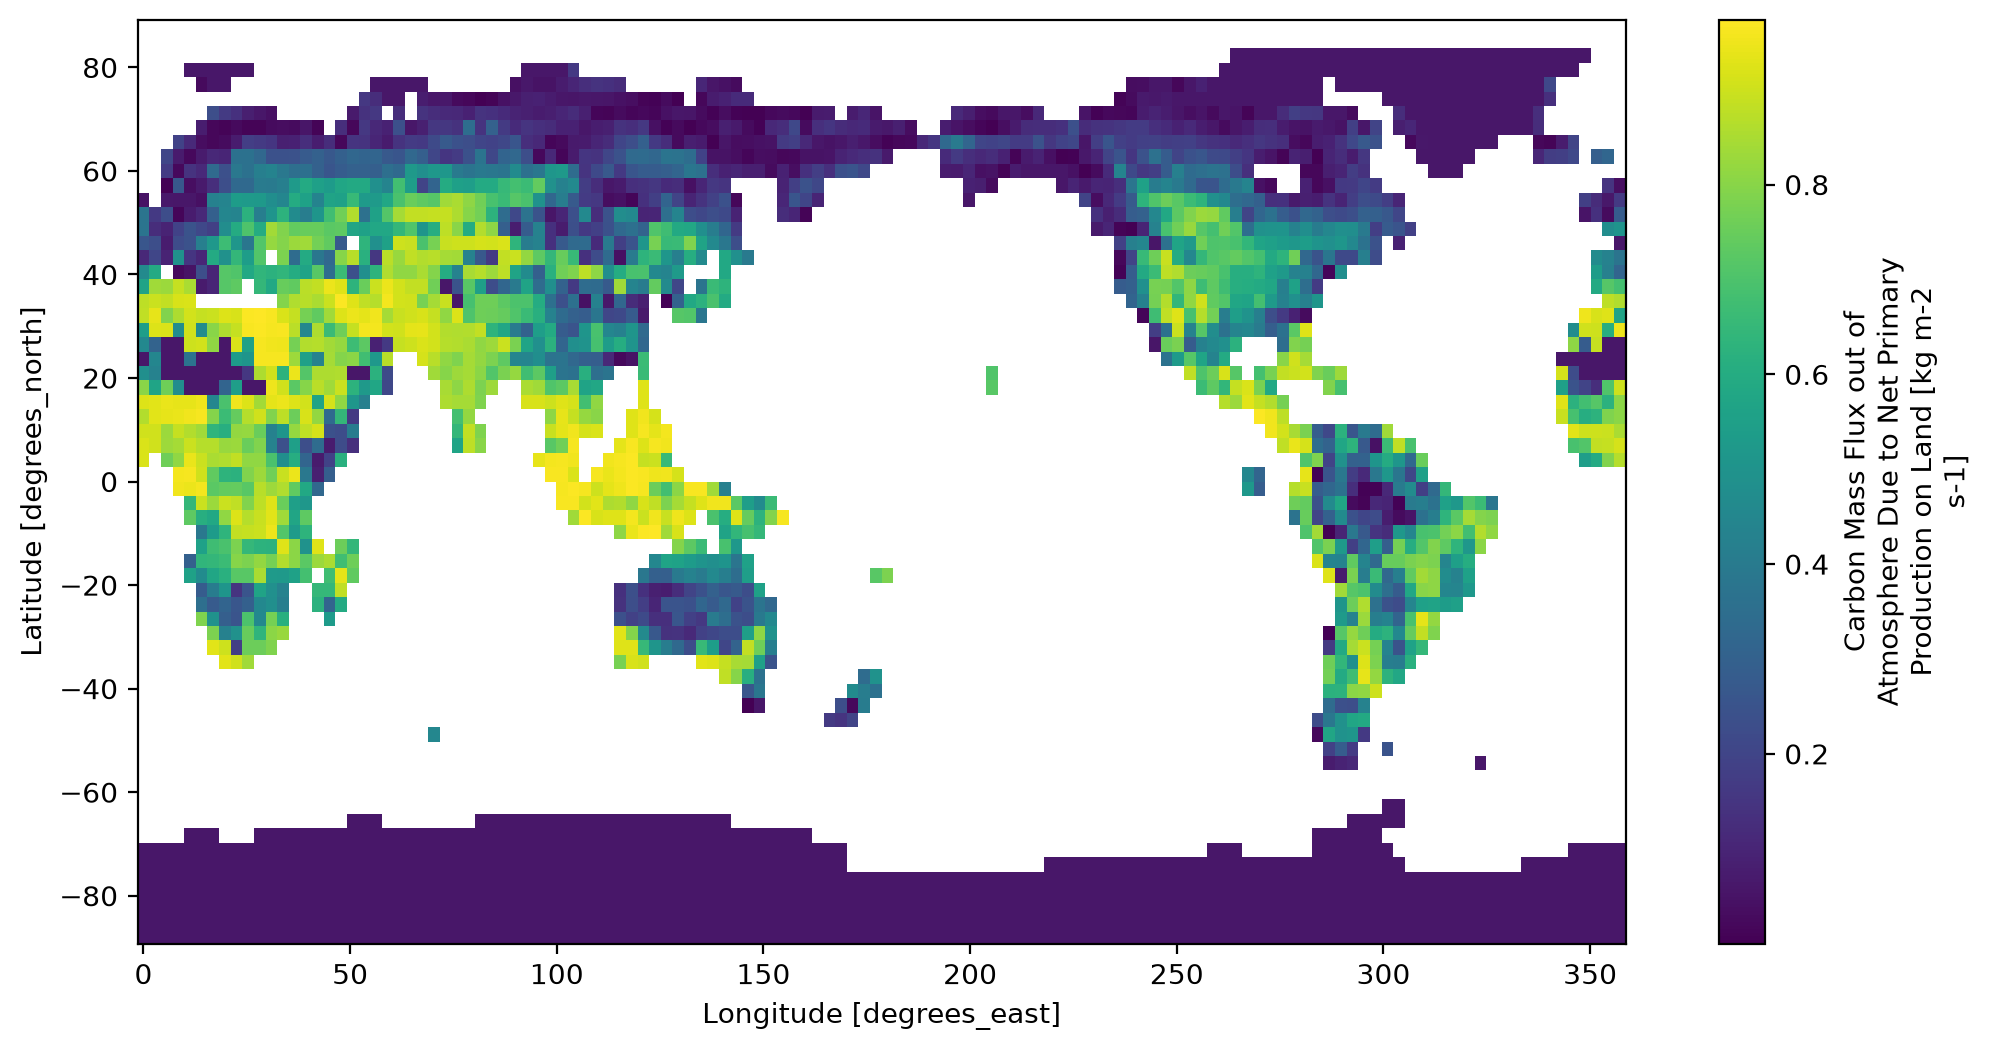

In [10]:
ct_var.npp.plot()

# Testing cross sample

## Idea 0 

use TGAV as one of the predictors. Pretty sure won't work because think not being able to use hist pattern on global NPP to predict future means the patterns (parameters) are different at different temps. Using TGAV as the predictor won't lead to temperature varying patterns (parameters). But check to be sure. 



## Idea 1 

We have 1950-2014 pattern and 2015-2100 pattern from CanESM5.

What if we additionally interpolate from historical pattern params to future pattern params?

$ (int, beta)_t = t*(int,beta)_{hist} + (1-t) * (int, beta)_{585} $

So then we could take the pattern of how the historical pattern evolves over time from CanESM5 and 
apply to the historical pattern(s) from TRENDY.

- absolutely an assumption and there would be caveats eg we are specifcally applying the CanESM5 ssp585 time evolution to TRENDY historical because we can show for CanESM5 (other SSPs) that just using history to estimate 585 is wrong. 

- Don't see a way around extrapolating if we want to use TRENDY. But we could look at a couple ESMs and Scenarios 

- This would also essentially move things out of sync in the feedback. We'd be applying a 585 pattern to a hector trajectory that isn't necessarily getting to 585. 

- how much do the spatial patterns differ by ESM


/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


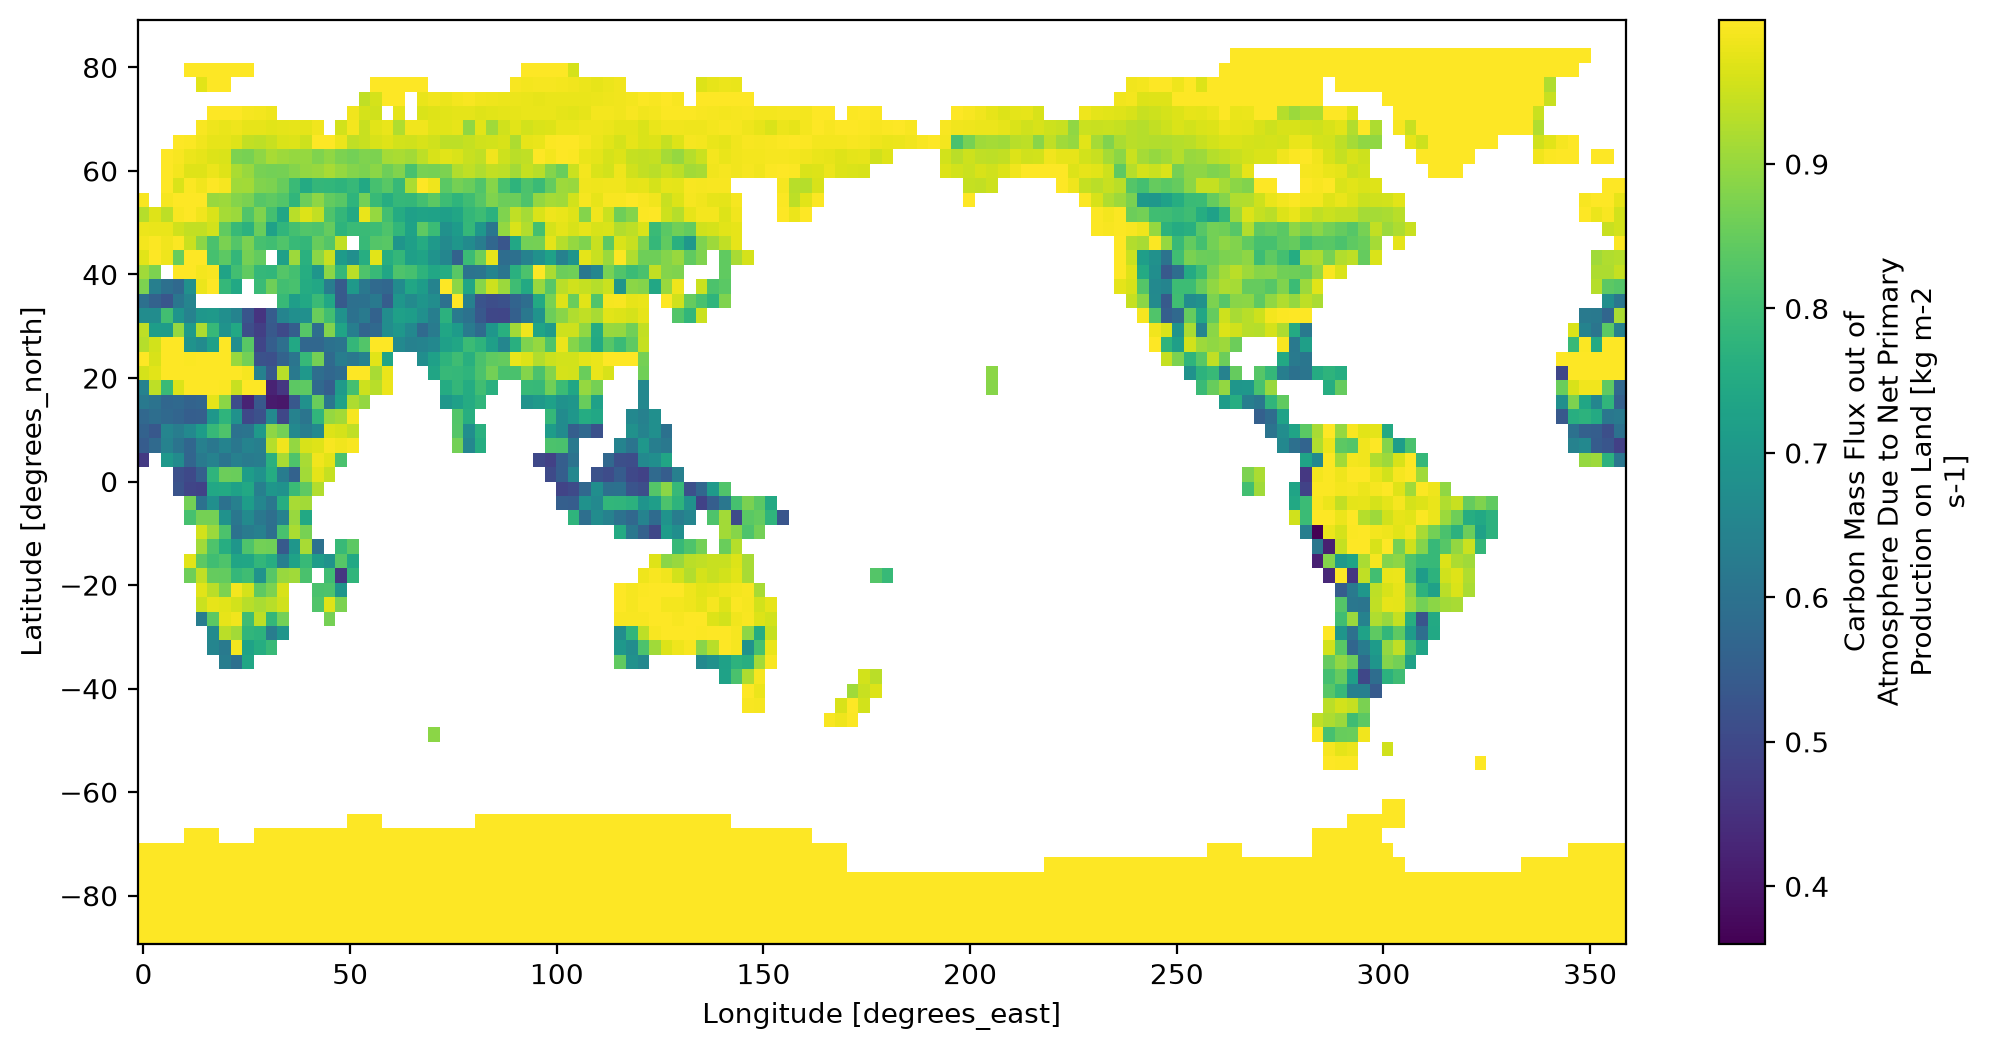

In [11]:
# Idea 0: historical pattern using GSAT as regressor, evaluate that pattern, then test that pattern on ssp585 data

# indep var
hist_gsat = pd.read_csv("cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr = xr.Dataset({'GSAT': xr.DataArray(hist_gsat['value']-273.16,
                                             coords = [field['time']], 
                                             dims = ['time'])}) 
x = global_xr['GSAT'].values.reshape(-1,1)


# dependent var
testglobal = field.copy()
stacked = testglobal.stack(unifiedspatial=['lat', 'lon']).copy()
y = stacked[VAR].fillna(0).values


# do regression
linear_regressor = skl.linear_model.LinearRegression(fit_intercept = True)
linear_regressor.fit(x,y)

# shape params
tmp = linear_regressor.coef_.T
beta = xr.Dataset({'beta': xr.DataArray(linear_regressor.coef_.T, 
                                        coords = [['estimated_param'], stacked.unifiedspatial], 
                                        dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()
intercept = xr.Dataset({'intercept': xr.DataArray(linear_regressor.intercept_.reshape(tmp.shape),
                                                   coords = [['estimated_param'], stacked.unifiedspatial], 
                                                   dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()

yhat = beta['beta'] * global_xr['GSAT'] + intercept['intercept']
yhat = yhat.sel(param='estimated_param').drop_vars('param') .copy()
yhat = yhat.transpose(*("lat", "lon", "time")).rename(VAR).copy()


# evaluate this pattern
# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

ns.npp.plot()

/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


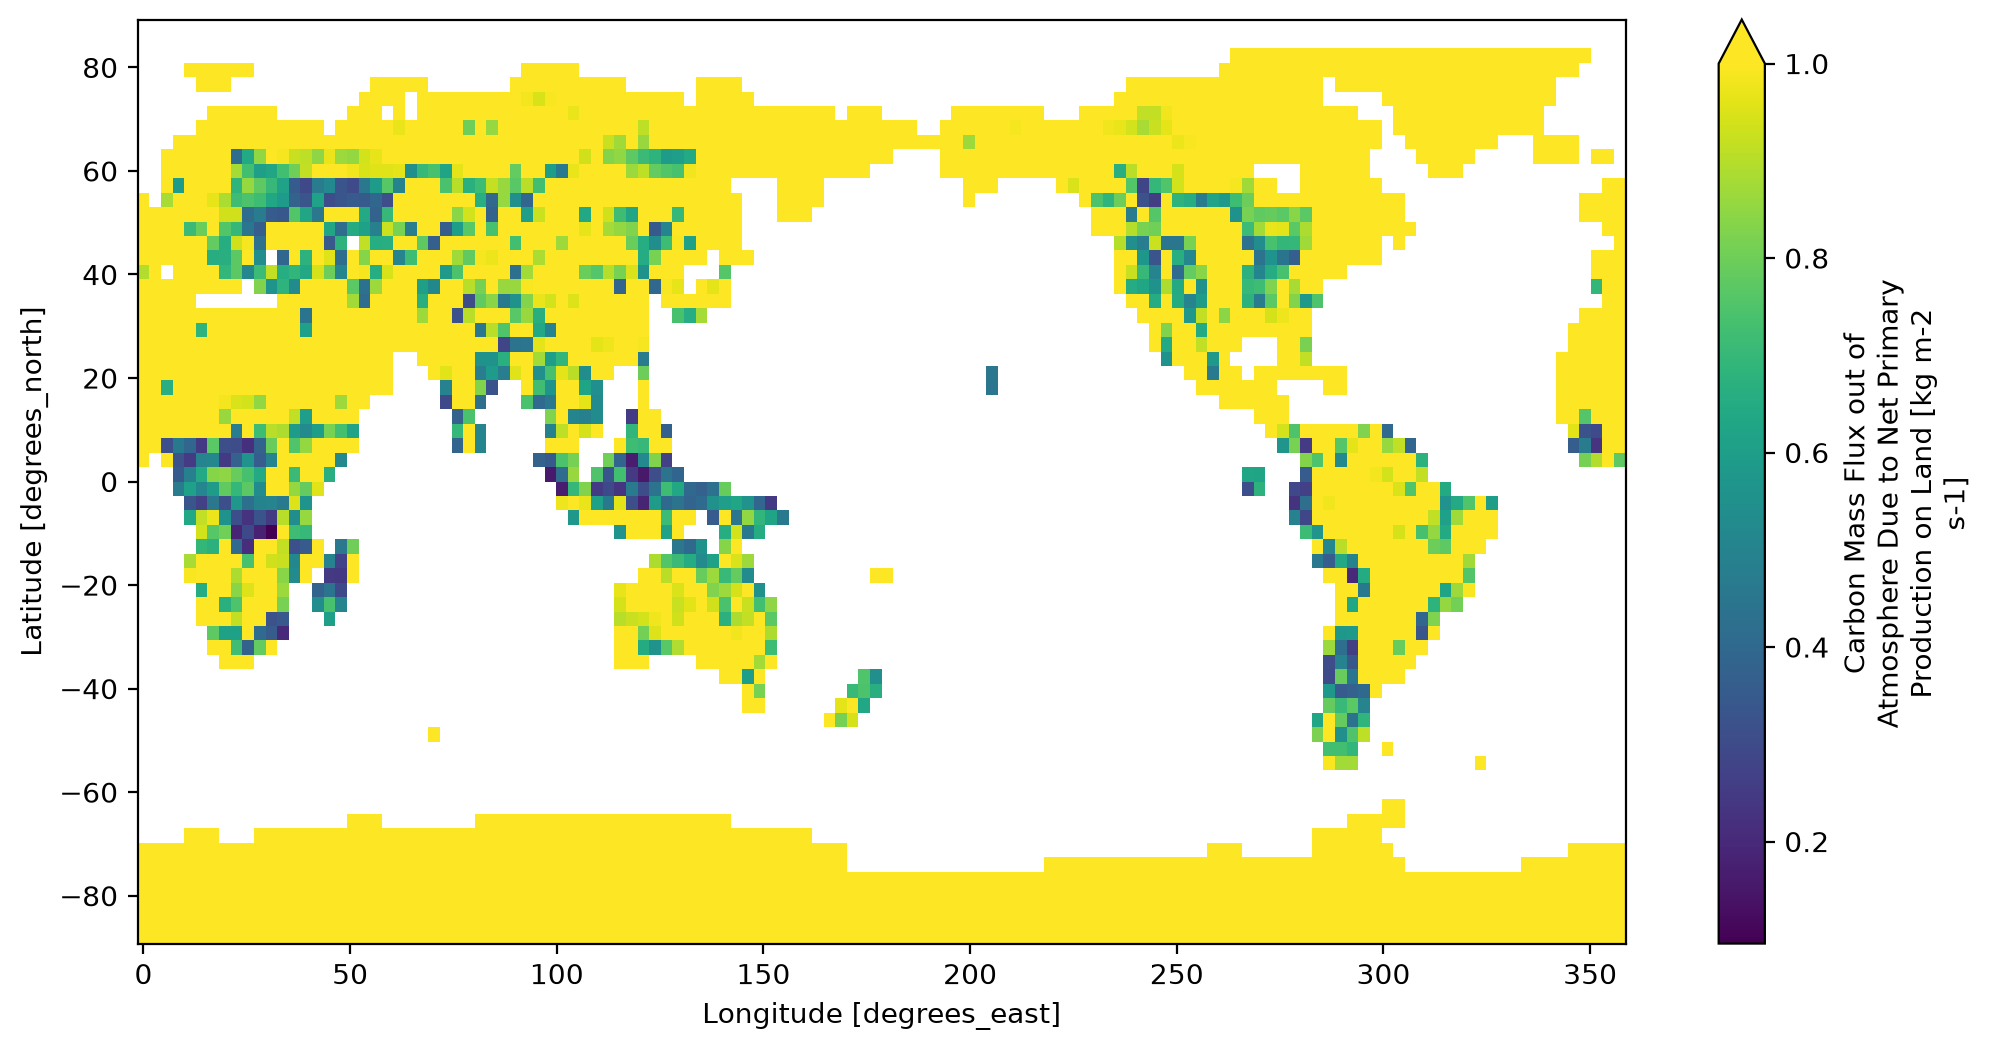

In [12]:
# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"


# apply pattern to SSP585 data
fut_gsat = pd.read_csv("cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr_fut = xr.Dataset({'GSAT': xr.DataArray(fut_gsat['value']-273.16,
                                             coords = [field_fut['time']], 
                                             dims = ['time'])}) 



yhat_fut = beta['beta'] * global_xr_fut['GSAT'] + intercept['intercept']
yhat_fut = yhat_fut.sel(param='estimated_param').drop_vars('param') .copy()
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).rename(VAR).copy()



# errors
var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field_fut
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs


ns.npp.plot(vmax = 1)


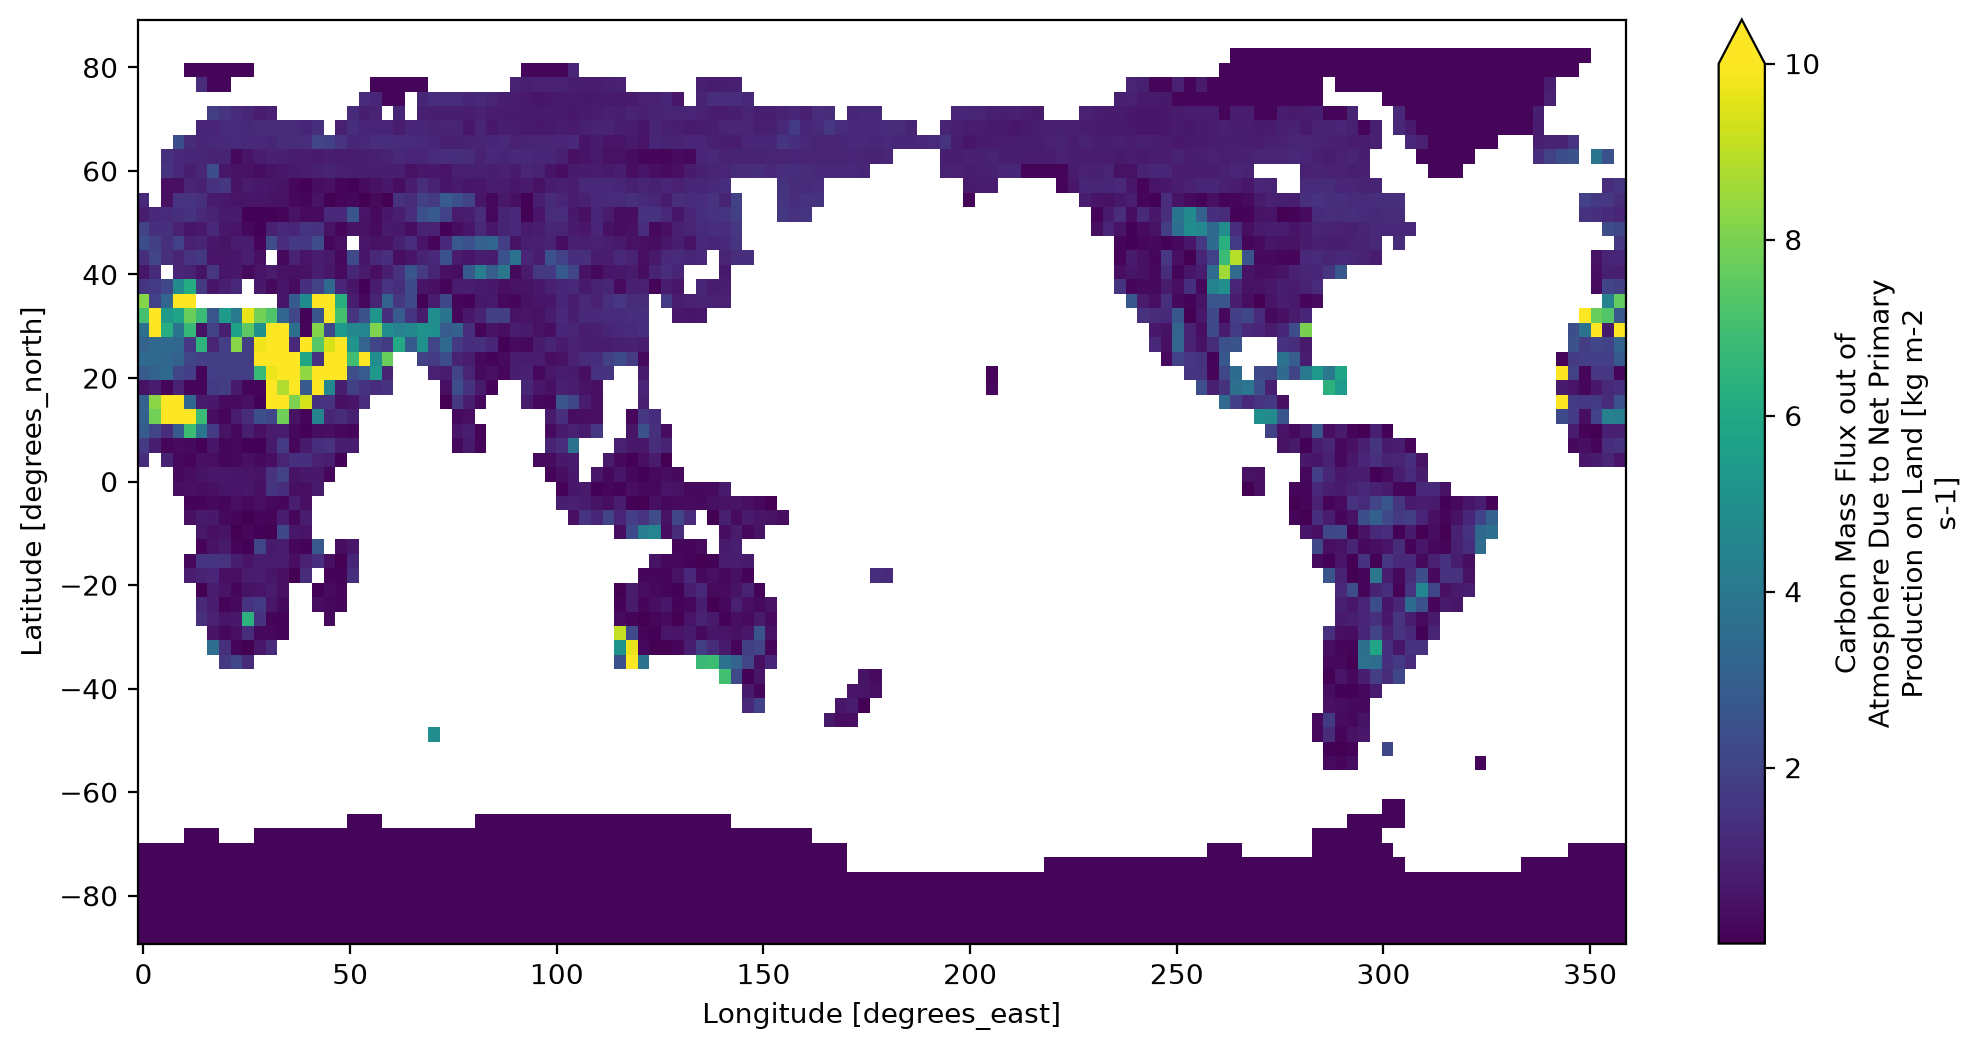

In [13]:
# continue evaluating - drop the one really bad grid cell so can see how things are elsewhere
ct_bias.npp.plot(vmax = 10)

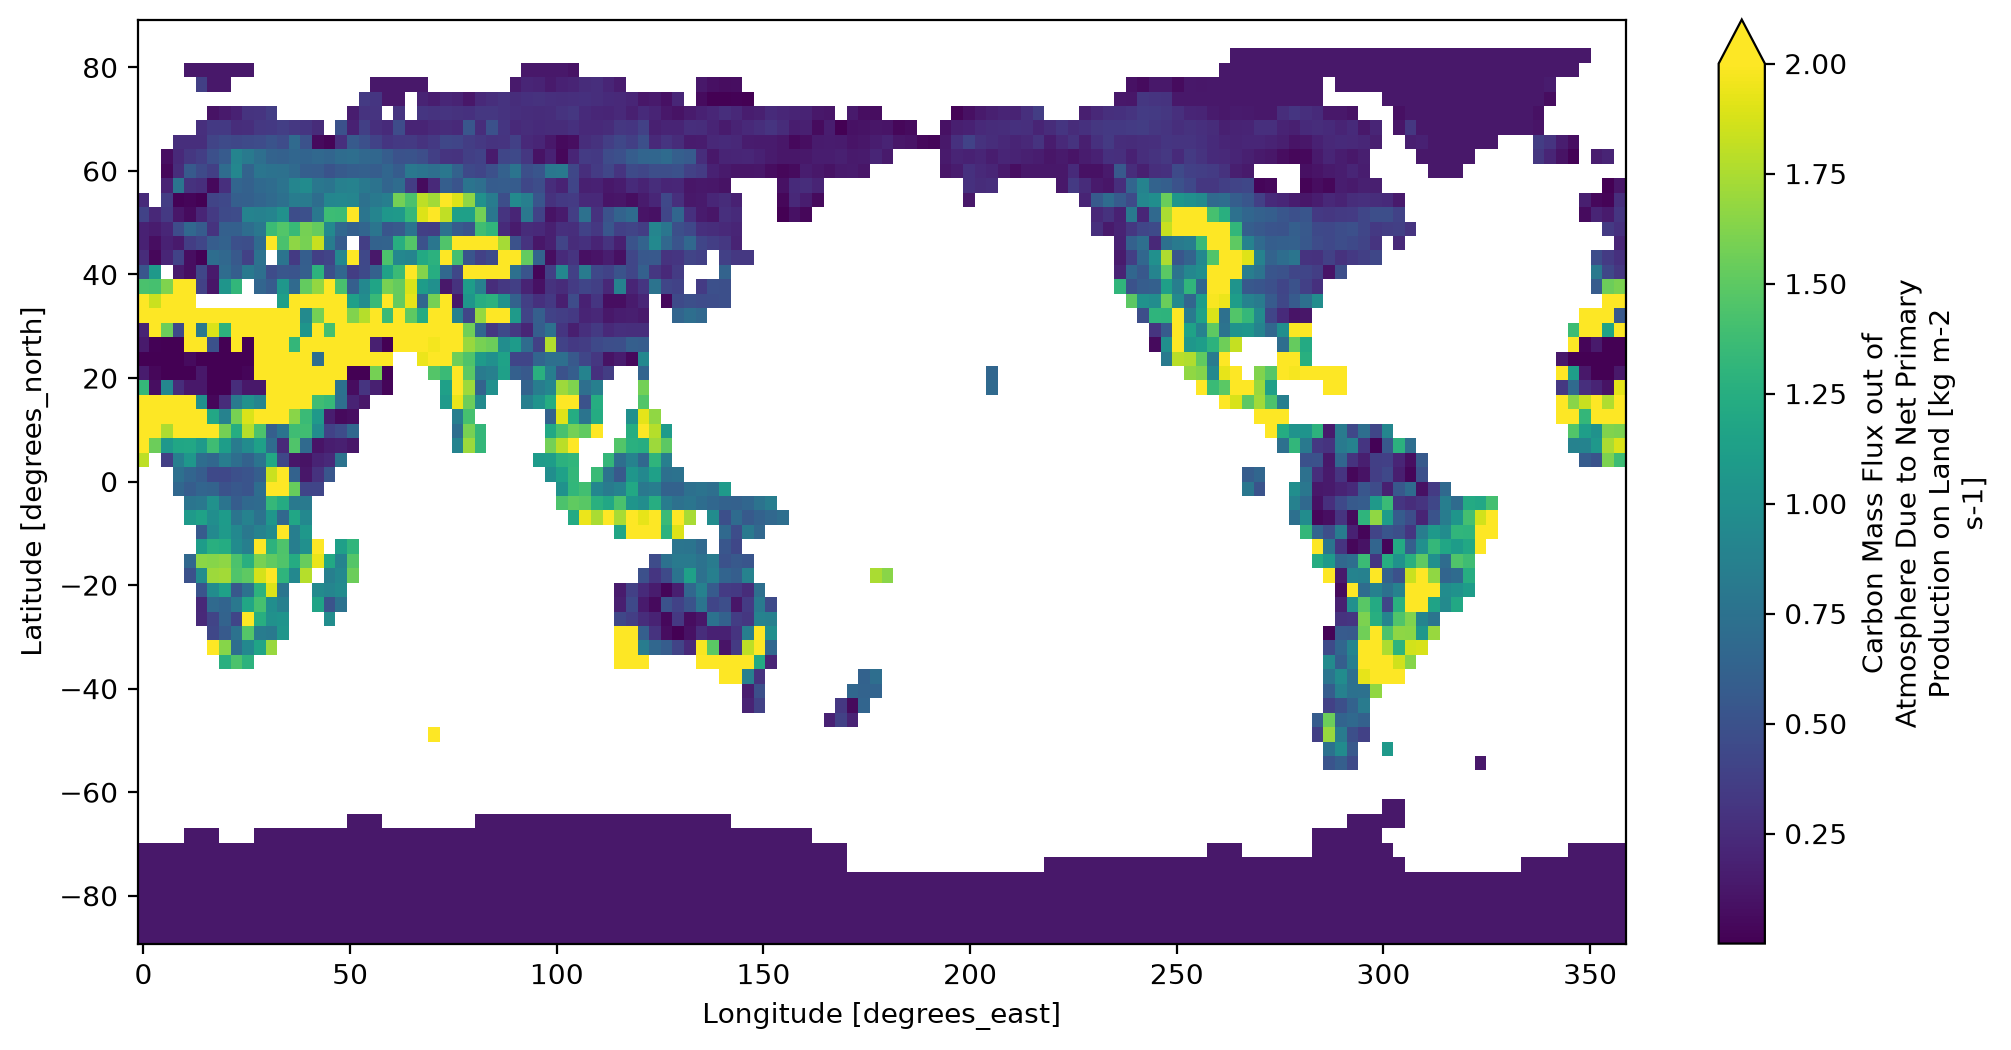

In [14]:
ct_var.npp.plot(vmax   = 2)

## Idea 2


Patterns by warming level (stitches inspired)

- this is stitches and using stitches to write the validation paper would be a lot more straightforward

- but it would probably very slow in an actual GCAM run, especially since we'd be generating gridded data when we only need GCAM region level. 

- We also don't really care about variability, which we'd be spending time creating and then smoothing back out if we use stitches.

- but we could mimic stitches with the patterns.


- Easy test: is Hector global NPP at +1deg the same whether that happens in 2070 or 2040? Assume not because history matters more in terrestrial: The running change in LUC from veg for NPP and soil temp for Rh may be enough to decouple from warming level.  

- Maybe decent actually based on below tests. Then the next step is to do the following including cross-check, because the spatial patterns might be different by scenario even for the same levels of warming.

But if somehow it does:

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSp585 by subsetting the SSP585 data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from historical by subsetting the data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSP245 by subsetting the data to years where each warming level is that temperature change.

- cross check those SSP specific patterns to make sure they are just tied to warming level.

- learn the trendy historical patterns by warming level and apply them that way. 

- Caveat: the warming levels seen in TRENDY history won't be very broad. still have to figure out a way to extrapolate to higher levels to get to the future. At that point, gets ESM and SSP specific just like in Idea 1. 

- less issue of getting out of sync because we can just use Hector Tgav to pick which warming level pattern to use (independent of scenario).





- autoregressive won't work because will depend on not just time but land use at each time whih differs by scenario





In [15]:
hector = pd.read_csv('hector_npp_rh_gsat_long.csv')

In [16]:
### NBP is wrong, need hector runs for NPP and Rh separately but otherwise this is code
NPP = hector[hector.variable == "NPP"]
Rh = hector[hector.variable == "RH"]

gsat = hector[hector.variable == "global_tas"]

In [77]:
f1 = gsat[gsat.value >= 1.75].copy()

f2 = f1[f1.value < 2.0].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)


NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say things are basically the same.

scenario
1pctCO2          78.350998
1pctCO2-4xext    78.350998
abruptx2CO2      81.499044
ssp119           60.817446
ssp126           62.107197
ssp245           62.457445
ssp370           62.776627
ssp434           58.513427
ssp460           63.212561
ssp534-over      56.599997
ssp585           62.061040
Name: value, dtype: float64

So NPP ranges 60-62.5 for warming between 1.5-2 for SSP126, 245, 370, 585, 460 aka not diagnostic or overshoot



In [18]:
f1 = gsat[gsat.value >= 0.5].copy()

f2 = f1[f1.value < 0.75].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)

NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

scenario
1pctCO2          65.083774
1pctCO2-4xext    65.083774
abruptx2CO2      81.499044
impulsex2CO2     61.628408
ssp119           59.083078
ssp126           59.083078
ssp245           59.083078
ssp370           59.083078
ssp434           59.083078
ssp460           59.083078
ssp534-over      59.083078
ssp585           59.083078
Name: value, dtype: float64

In [19]:
f1 = gsat[gsat.value >= 3.5].copy()

f2 = f1[f1.value < 3.75].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

Rh['ids'] = Rh[['scenario']] + Rh[['year']].values.astype(str)

Rh[Rh['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

scenario
1pctCO2          81.014212
1pctCO2-4xext    81.014212
abruptx4CO2      71.020760
ssp370           64.978504
ssp460           70.158327
ssp585           64.958327
Name: value, dtype: float64

## Test it with patterns

In [20]:
# bin GSAT
hist_gsat = pd.read_csv("cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
fut_gsat = pd.read_csv("cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")

hist_gsat['value'] = hist_gsat['value'] - 273.15
fut_gsat['value'] = fut_gsat['value'] - 273.15

hist_avg = hist_gsat[hist_gsat['year'].between(1850, 1900)]['value'].mean()

hist_gsat['value'] = hist_gsat['value'] - hist_avg
fut_gsat['value'] = fut_gsat['value']  - hist_avg

# And smooth
hist_gsat['smooth_value'] = hist_gsat['value'].rolling(window=13).mean()
fut_gsat['smooth_value'] = fut_gsat['value'].rolling(window=13).mean()

hist_gsat['smooth_value'] = hist_gsat['smooth_value'].fillna(hist_gsat['value'])
fut_gsat['smooth_value'] = fut_gsat['smooth_value'].fillna(fut_gsat['value'])


In [51]:

binsize = 0.5
binedges = np.arange(-5, 10, binsize, )

hist_gsat['group'] = pd.cut(hist_gsat['smooth_value'], bins= binedges)
fut_gsat['group'] = pd.cut(fut_gsat['smooth_value'], bins= binedges)


hist_gsat

,variable,experiment,units,frequency,ensemble,model,year,value,smooth_value,group
0,tas,historical,K,mon,r10i1p1f1,CanESM5,1850,-0.225055,-0.225055,"(-0.5, 0.0]"
1,tas,historical,K,mon,r10i1p1f1,CanESM5,1851,-0.164105,-0.164105,"(-0.5, 0.0]"
2,tas,historical,K,mon,r10i1p1f1,CanESM5,1852,-0.117305,-0.117305,"(-0.5, 0.0]"
3,tas,historical,K,mon,r10i1p1f1,CanESM5,1853,-0.010311,-0.010311,"(-0.5, 0.0]"
4,tas,historical,K,mon,r10i1p1f1,CanESM5,1854,-0.212809,-0.212809,"(-0.5, 0.0]"
...,...,...,...,...,...,...,...,...,...,...
160,tas,historical,K,mon,r10i1p1f1,CanESM5,2010,1.511339,1.230223,"(1.0, 1.5]"
161,tas,historical,K,mon,r10i1p1f1,CanESM5,2011,1.650005,1.292668,"(1.0, 1.5]"
162,tas,historical,K,mon,r10i1p1f1,CanESM5,2012,1.754281,1.358024,"(1.0, 1.5]"
163,tas,historical,K,mon,r10i1p1f1,CanESM5,2013,1.676063,1.411920,"(1.0, 1.5]"


In [52]:
grouped_year_ranges = pd.DataFrame()    
for group_name, group_df in hist_gsat.groupby('group'):
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in historical


for group_name, group_df in fut_gsat.groupby('group'):
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in future

grouped_year_ranges

,scenario,ensemble,model,start_yr,stop_yr,group
0,historical,r10i1p1f1,CanESM5,1850,1918,"(-0.5, 0.0]"
1,historical,r10i1p1f1,CanESM5,1856,1996,"(0.0, 0.5]"
2,historical,r10i1p1f1,CanESM5,1997,2005,"(0.5, 1.0]"
3,historical,r10i1p1f1,CanESM5,2006,2014,"(1.0, 1.5]"
4,ssp585,r10i1p1f1,CanESM5,2015,2021,"(1.5, 2.0]"
5,ssp585,r10i1p1f1,CanESM5,2019,2038,"(2.0, 2.5]"
6,ssp585,r10i1p1f1,CanESM5,2039,2046,"(2.5, 3.0]"
7,ssp585,r10i1p1f1,CanESM5,2047,2053,"(3.0, 3.5]"
8,ssp585,r10i1p1f1,CanESM5,2054,2060,"(3.5, 4.0]"
9,ssp585,r10i1p1f1,CanESM5,2061,2066,"(4.0, 4.5]"


/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


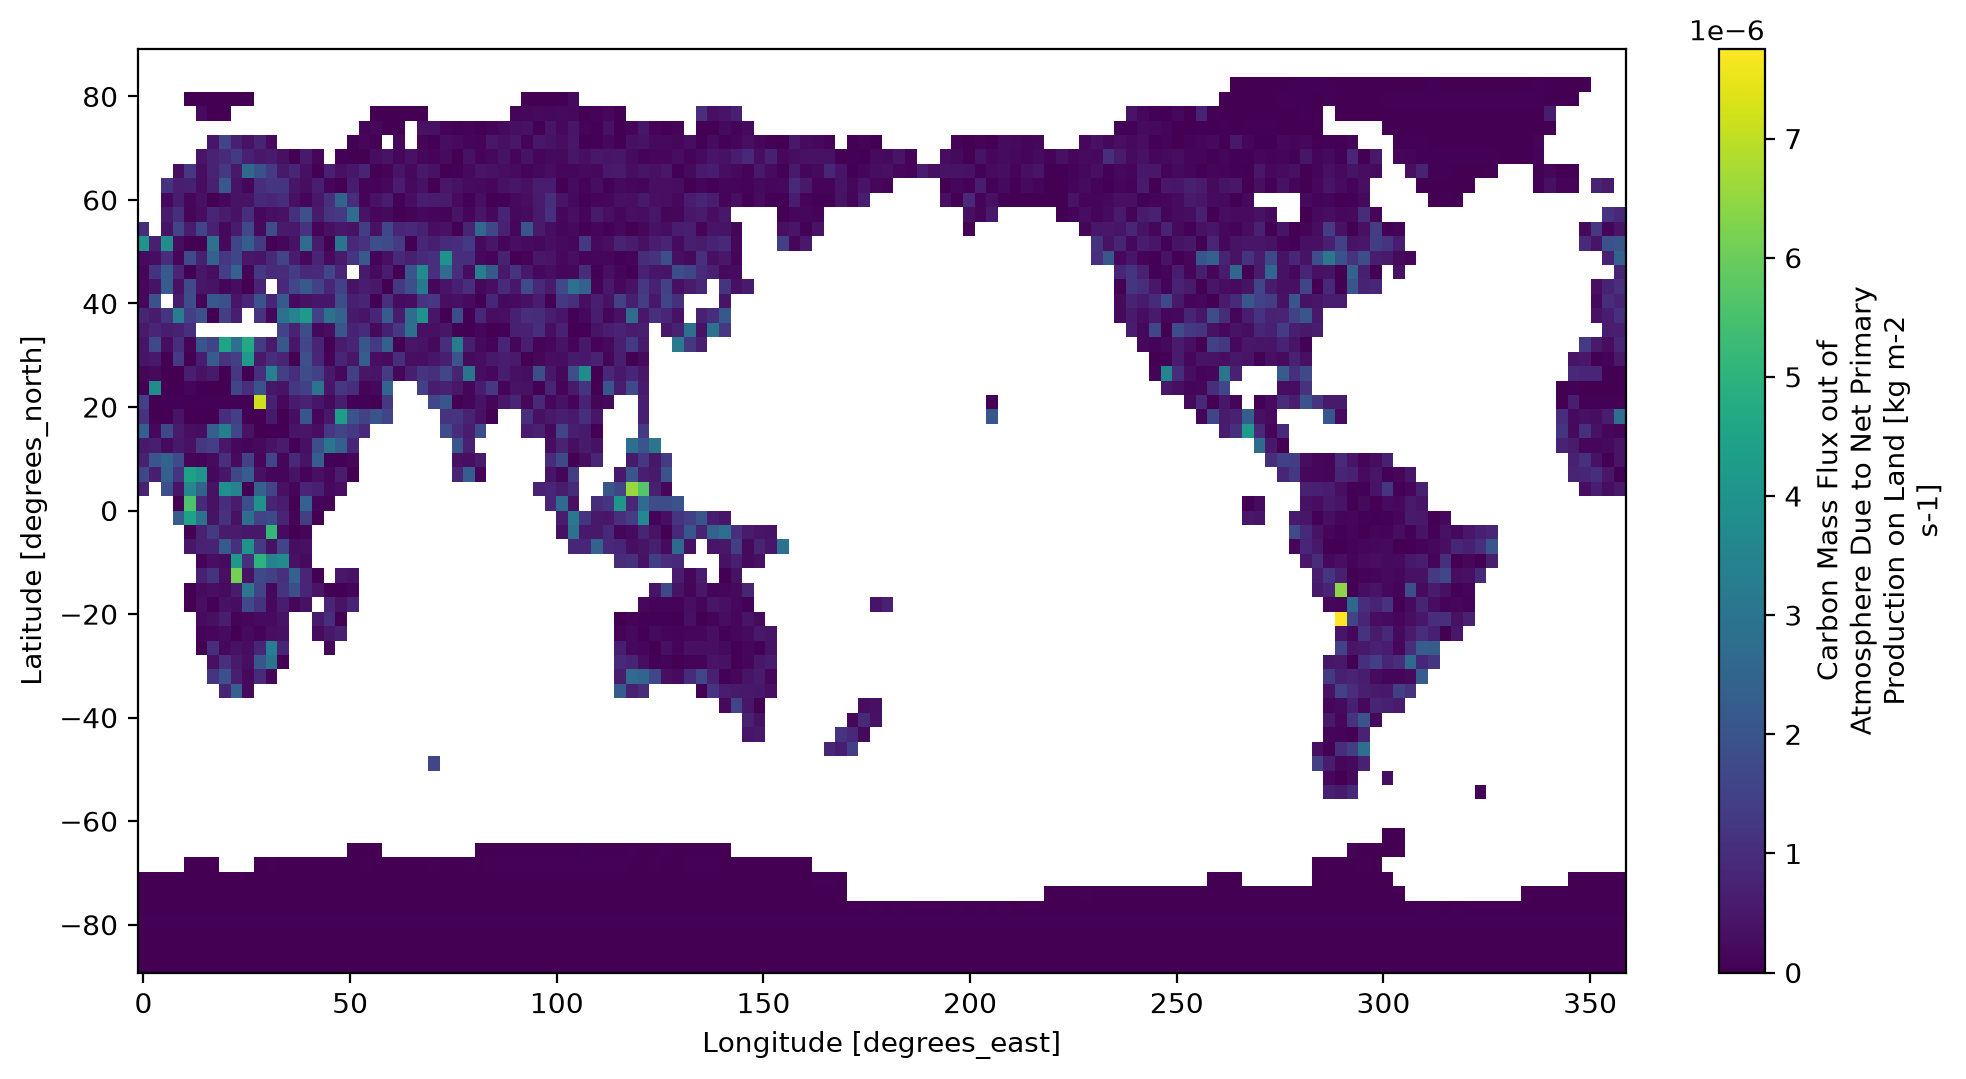

In [53]:
# Should properly smoosh all the data together  and loop over all groups
# Especially if pulling from all experiments + average over ensemble members.


# But because we are looking at hist vs ssp585, there isn't overlap.
# best we can do is train on (1.0,1.5] and test on (1.5, 2]. 
# Just manually filter to years for now

# train

tag = 'CanESM5_historical_r10i1p1f1n_npp_1to1p5'
field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc").sel(time= slice('2006','2014'))
cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values




# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')

ct_bias.npp.plot()

In [54]:
# evaluate on ssp585

# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc").sel(time= slice('2015','2021'))
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"



# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field_fut.dims) - {"time"} # define that will sum over every dim except time
global_ts_fut = field_fut.sum(other_dims, skipna=True)


# estimate field and compare to truth
yhat_fut = beta * global_ts_fut + intercept
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).copy()

# errors
var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field_fut
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


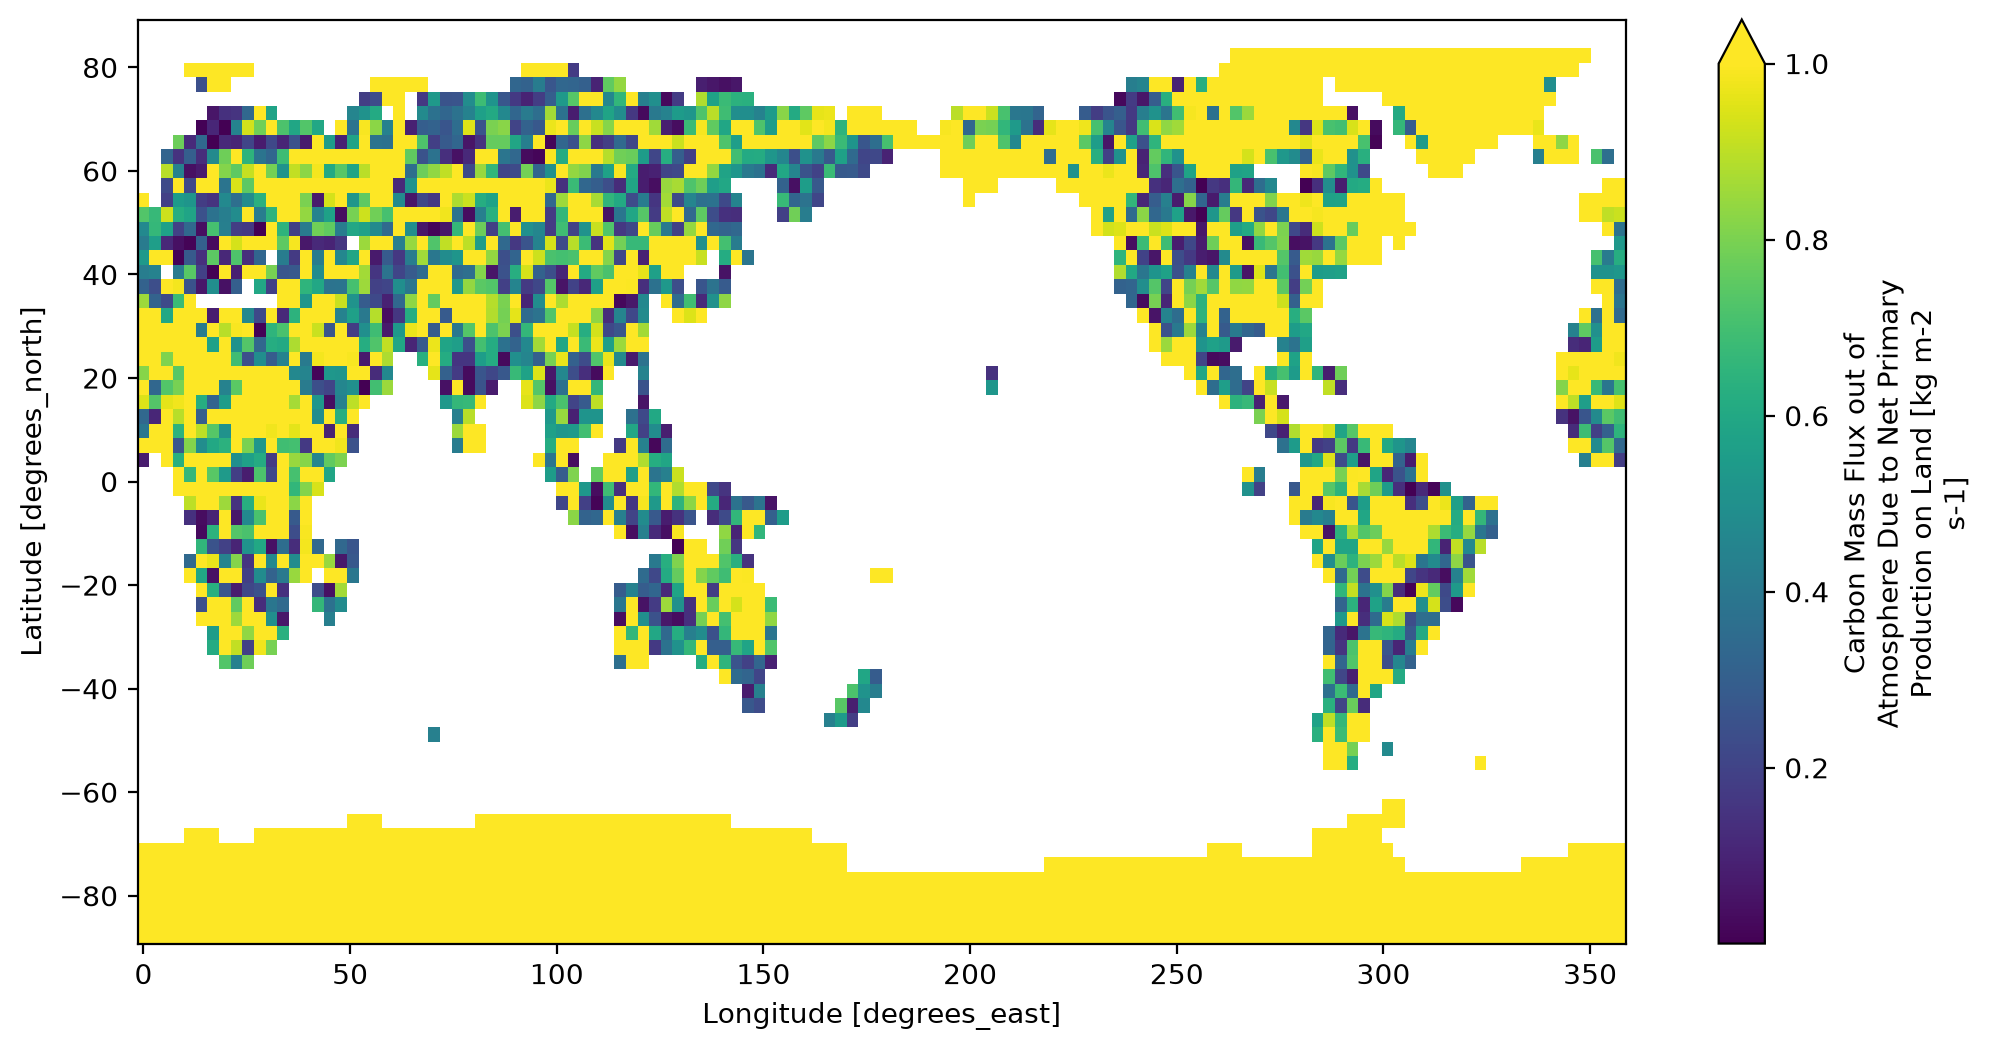

In [55]:
ct_bias.npp.plot(vmax = 1)

Improving over

# Ideal final test 

for every scenario with a specific bin (like 0.75 to 1.0 degC change),
learn the pattern for each scenario and for all the scenarios together.
Then evaluate all of the different patterns on the relevant range of global NPP

If the errors between each of those created maps are small, it means the pattern is
the same for each temperature bin regardless of SSP, and we can use the pattern on
all available data in that temperature bin.

further ideal:
- for ensemble avg for each ESMxScenario
- by GCAM region instead of gridded